# Machine Learning-Based Stroke Prediction: Evaluating the Impact of Data Preprocessing Techniques

## 03_Outliers: Outlier Analysis and IQR-Based Treatment

## Introduction

### Research Objective

The objective of this notebook is to investigate the impact of outlier treatment on the stroke prediction dataset. The analysis focuses on two continuous clinical variables: `bmi` and `avg_glucose_level`. These variables are important because extreme values may influence descriptive statistics, preprocessing decisions, and later machine learning model behaviour.

Outlier treatment is examined as a preprocessing step only. No machine learning models are trained in this notebook. The aim is to compare the original dataset with an IQR-treated dataset and to document how many records would be removed by this treatment.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PATH = PROJECT_ROOT / "data" / "healthcare-dataset-stroke-data.csv"
FIGURES_DIR = PROJECT_ROOT / "results" / "figures"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)
df["bmi"] = pd.to_numeric(df["bmi"], errors="coerce")

print(f"Original dataset shape: {df.shape}")
display(df.head())

Original dataset shape: (5110, 12)


,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


## Outlier Detection

Outliers are observations that fall substantially outside the central range of a variable. In healthcare datasets, outliers require careful interpretation because extreme values may represent genuine high-risk patients rather than data errors. Therefore, this notebook does not automatically claim that outliers are invalid; it evaluates the consequences of applying a standard statistical treatment.

The analysis uses the Interquartile Range (IQR) method. This method defines outliers as values below `Q1 - 1.5 * IQR` or above `Q3 + 1.5 * IQR`, where `Q1` is the 25th percentile, `Q3` is the 75th percentile, and `IQR = Q3 - Q1`.

In [2]:
def iqr_outlier_summary(dataframe, column):
    values = dataframe[column].dropna()
    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    mask = (dataframe[column] < lower_bound) | (dataframe[column] > upper_bound)
    return {
        "variable": column,
        "q1": q1,
        "q3": q3,
        "iqr": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": int(mask.sum()),
        "outlier_percentage": round(mask.mean() * 100, 2),
        "mask": mask
    }

bmi_iqr = iqr_outlier_summary(df, "bmi")
glucose_iqr = iqr_outlier_summary(df, "avg_glucose_level")

iqr_summary = pd.DataFrame([
    {key: value for key, value in bmi_iqr.items() if key != "mask"},
    {key: value for key, value in glucose_iqr.items() if key != "mask"}
]).round(3)

iqr_summary.to_csv(TABLES_DIR / "outlier_iqr_summary.csv", index=False)
display(iqr_summary)

,variable,q1,q3,iqr,lower_bound,upper_bound,outlier_count,outlier_percentage
0,bmi,23.500,33.10,9.600,9.100,47.500,110,2.15
1,avg_glucose_level,77.245,114.09,36.845,21.978,169.358,627,12.27


## BMI Analysis

BMI is analysed for outliers because it is a clinically meaningful body composition measure and may contain extreme values. Since the BMI column also contains missing values, the IQR thresholds are calculated using available non-missing BMI observations only. Missing BMI values are not treated as outliers in this notebook.

BMI lower bound: 9.10
BMI upper bound: 47.50
Detected BMI outliers: 110


,id,age,gender,bmi,stroke
21,13861,52.0,Female,48.9,1
113,41069,45.0,Female,56.6,1
254,32257,47.0,Female,50.1,0
258,28674,74.0,Female,54.6,0
270,72911,57.0,Female,60.9,0
333,1703,52.0,Female,54.7,0
341,38805,37.0,Female,48.2,0
358,66333,52.0,Male,64.8,0
430,53144,52.0,Female,54.7,0
462,18498,44.0,Female,49.8,0


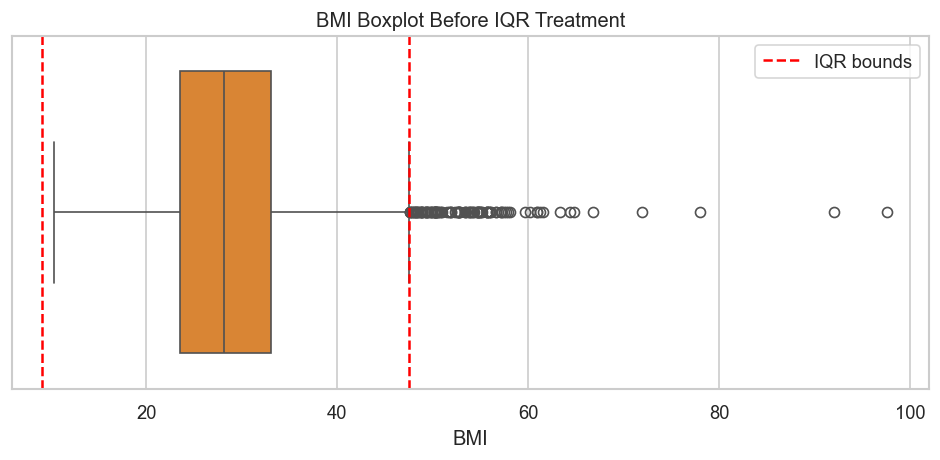

In [3]:
bmi_outliers = df.loc[bmi_iqr["mask"], ["id", "age", "gender", "bmi", "stroke"]]
bmi_outliers.to_csv(TABLES_DIR / "bmi_outlier_records.csv", index=False)

print(f"BMI lower bound: {bmi_iqr['lower_bound']:.2f}")
print(f"BMI upper bound: {bmi_iqr['upper_bound']:.2f}")
print(f"Detected BMI outliers: {bmi_iqr['outlier_count']}")
display(bmi_outliers.head(10))

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="bmi", color="#F58518")
plt.axvline(bmi_iqr["lower_bound"], color="red", linestyle="--", label="IQR bounds")
plt.axvline(bmi_iqr["upper_bound"], color="red", linestyle="--")
plt.title("BMI Boxplot Before IQR Treatment")
plt.xlabel("BMI")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "bmi_boxplot_before_iqr_treatment.png", bbox_inches="tight")
plt.show()

## Glucose Analysis

`avg_glucose_level` is analysed because unusually high glucose values may affect distributional shape and later model behaviour. In a clinical context, high glucose values can be meaningful rather than erroneous, so their removal should be justified carefully. The IQR method provides a consistent statistical rule for identifying extreme glucose observations.

Glucose lower bound: 21.98
Glucose upper bound: 169.36
Detected glucose outliers: 627


,id,age,gender,avg_glucose_level,stroke
0,9046,67.0,Male,228.69,1
1,51676,61.0,Female,202.21,1
3,60182,49.0,Female,171.23,1
4,1665,79.0,Female,174.12,1
5,56669,81.0,Male,186.21,1
13,8213,78.0,Male,219.84,1
14,5317,79.0,Female,214.09,1
16,56112,64.0,Male,191.61,1
17,34120,75.0,Male,221.29,1
19,25226,57.0,Male,217.08,1


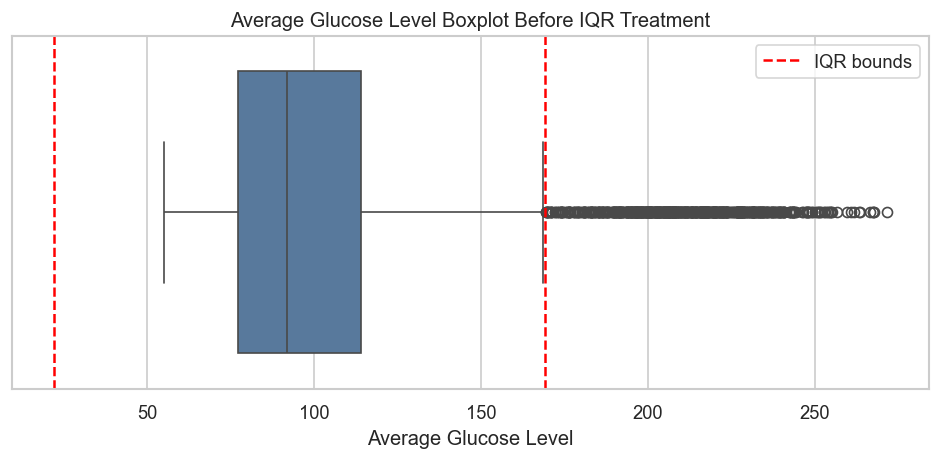

In [4]:
glucose_outliers = df.loc[glucose_iqr["mask"], ["id", "age", "gender", "avg_glucose_level", "stroke"]]
glucose_outliers.to_csv(TABLES_DIR / "glucose_outlier_records.csv", index=False)

print(f"Glucose lower bound: {glucose_iqr['lower_bound']:.2f}")
print(f"Glucose upper bound: {glucose_iqr['upper_bound']:.2f}")
print(f"Detected glucose outliers: {glucose_iqr['outlier_count']}")
display(glucose_outliers.head(10))

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x="avg_glucose_level", color="#4C78A8")
plt.axvline(glucose_iqr["lower_bound"], color="red", linestyle="--", label="IQR bounds")
plt.axvline(glucose_iqr["upper_bound"], color="red", linestyle="--")
plt.title("Average Glucose Level Boxplot Before IQR Treatment")
plt.xlabel("Average Glucose Level")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "glucose_boxplot_before_iqr_treatment.png", bbox_inches="tight")
plt.show()

## IQR Method

The IQR-treated dataset is created by removing any record identified as an outlier in either BMI or average glucose level. This produces a stricter treated dataset because a record is removed if it violates the IQR rule for at least one of the two variables. The resulting dataset is saved for possible sensitivity analysis in later preprocessing work.

In [5]:
combined_outlier_mask = bmi_iqr["mask"] | glucose_iqr["mask"]
outlier_records = df.loc[combined_outlier_mask].copy()
iqr_treated_df = df.loc[~combined_outlier_mask].copy()

outlier_records.to_csv(TABLES_DIR / "combined_iqr_outlier_records.csv", index=False)
iqr_treated_df.to_csv(PROCESSED_DIR / "stroke_iqr_treated.csv", index=False)

total_outliers_detected = int(combined_outlier_mask.sum())
rows_removed = len(df) - len(iqr_treated_df)

treatment_summary = pd.DataFrame({
    "metric": [
        "Original rows",
        "IQR-treated rows",
        "BMI outliers detected",
        "Glucose outliers detected",
        "Unique records flagged as outliers",
        "Rows removed"
    ],
    "value": [
        len(df),
        len(iqr_treated_df),
        bmi_iqr["outlier_count"],
        glucose_iqr["outlier_count"],
        total_outliers_detected,
        rows_removed
    ]
})

treatment_summary.to_csv(TABLES_DIR / "outlier_treatment_summary.csv", index=False)
display(treatment_summary)

,metric,value
0,Original rows,5110
1,IQR-treated rows,4401
2,BMI outliers detected,110
3,Glucose outliers detected,627
4,Unique records flagged as outliers,709
5,Rows removed,709


## Before vs After Comparison

The original dataset and IQR-treated dataset are compared to assess how much the treatment changes the two variables of interest and the target class distribution. This is important because outlier removal may remove clinically meaningful high-risk records, including stroke cases.

,dataset,rows,bmi_mean,bmi_median,bmi_std,glucose_mean,glucose_median,glucose_std,stroke_cases,stroke_percentage
0,Original Dataset,5110,28.893,28.1,7.854,106.148,91.885,45.284,249,4.873
1,IQR-Treated Dataset,4401,27.812,27.4,6.721,91.484,88.040,22.664,165,3.749


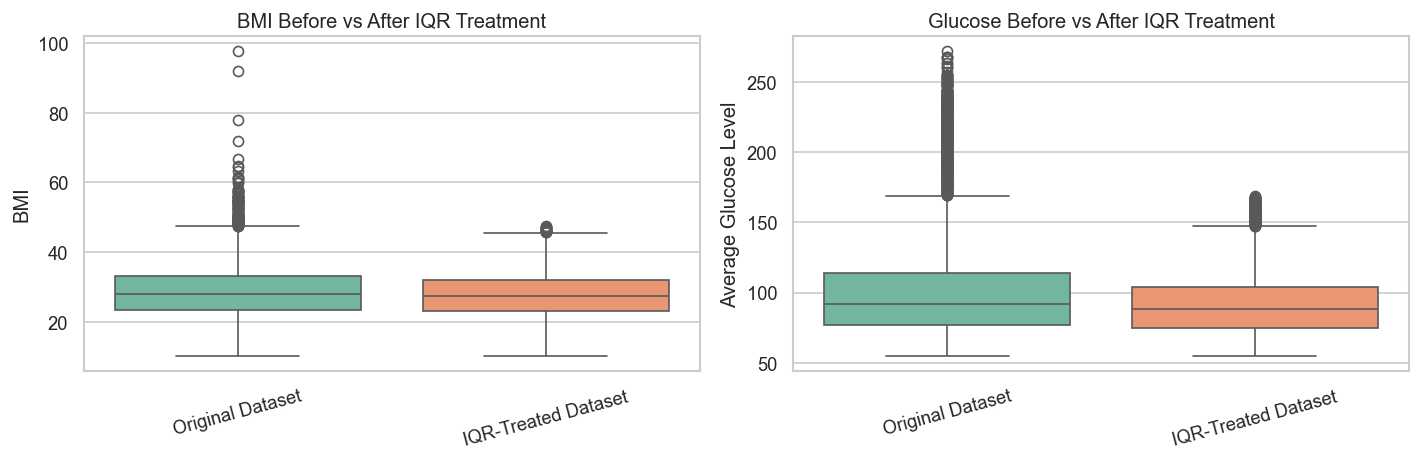

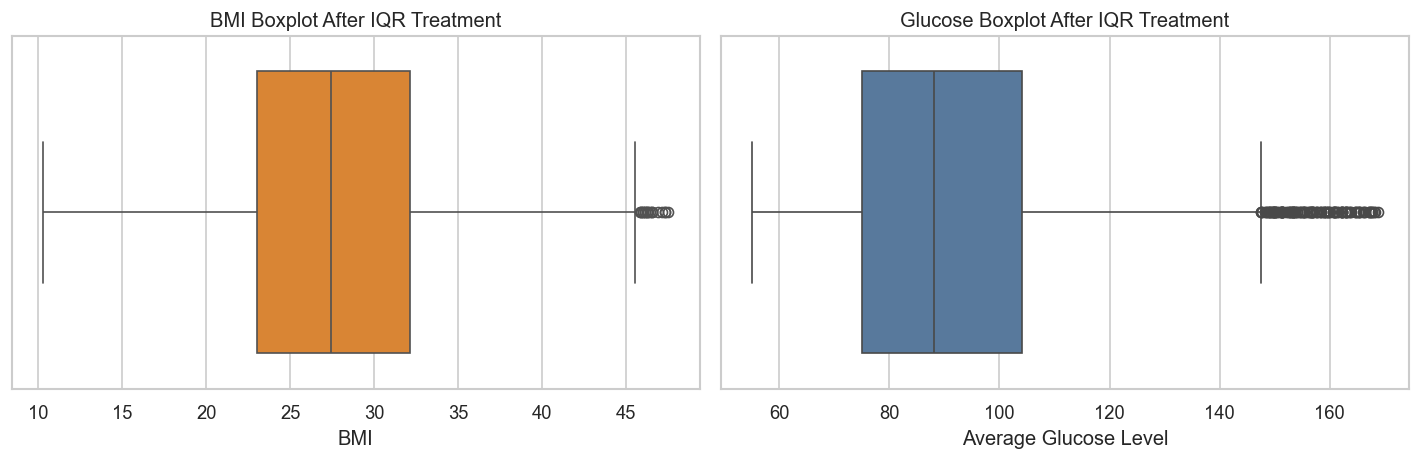

In [6]:
comparison_rows = []
for dataset_name, dataset in [("Original Dataset", df), ("IQR-Treated Dataset", iqr_treated_df)]:
    comparison_rows.append({
        "dataset": dataset_name,
        "rows": len(dataset),
        "bmi_mean": dataset["bmi"].mean(),
        "bmi_median": dataset["bmi"].median(),
        "bmi_std": dataset["bmi"].std(),
        "glucose_mean": dataset["avg_glucose_level"].mean(),
        "glucose_median": dataset["avg_glucose_level"].median(),
        "glucose_std": dataset["avg_glucose_level"].std(),
        "stroke_cases": int(dataset["stroke"].sum()),
        "stroke_percentage": dataset["stroke"].mean() * 100
    })

before_after_comparison = pd.DataFrame(comparison_rows).round(3)
before_after_comparison.to_csv(TABLES_DIR / "outlier_before_after_comparison.csv", index=False)
display(before_after_comparison)

boxplot_df = pd.concat([
    df.assign(dataset="Original Dataset"),
    iqr_treated_df.assign(dataset="IQR-Treated Dataset")
], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=boxplot_df, x="dataset", y="bmi", hue="dataset", palette="Set2", legend=False, ax=axes[0])
axes[0].set_title("BMI Before vs After IQR Treatment")
axes[0].set_xlabel("")
axes[0].set_ylabel("BMI")
axes[0].tick_params(axis="x", rotation=15)

sns.boxplot(data=boxplot_df, x="dataset", y="avg_glucose_level", hue="dataset", palette="Set2", legend=False, ax=axes[1])
axes[1].set_title("Glucose Before vs After IQR Treatment")
axes[1].set_xlabel("")
axes[1].set_ylabel("Average Glucose Level")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "outlier_before_after_boxplots.png", bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=iqr_treated_df, x="bmi", color="#F58518", ax=axes[0])
axes[0].set_title("BMI Boxplot After IQR Treatment")
axes[0].set_xlabel("BMI")

sns.boxplot(data=iqr_treated_df, x="avg_glucose_level", color="#4C78A8", ax=axes[1])
axes[1].set_title("Glucose Boxplot After IQR Treatment")
axes[1].set_xlabel("Average Glucose Level")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "outlier_boxplots_after_iqr_treatment.png", bbox_inches="tight")
plt.show()

## Discussion

The IQR method provides a systematic and reproducible approach to outlier detection. It is particularly useful for exploratory comparison because it does not require distributional assumptions such as normality. However, in a clinical dataset, statistical outliers may represent meaningful patient profiles rather than measurement errors. For example, high glucose values may be clinically important indicators of metabolic risk and should not be removed without justification.

The comparison between the original and IQR-treated datasets shows the direct cost of outlier removal in terms of records lost. This matters for stroke prediction because the positive stroke class is already small. If outlier removal disproportionately removes stroke cases or high-risk patients, it could weaken the ability of later models to learn clinically relevant patterns.

## Conclusion

This notebook identified outliers in BMI and average glucose level using the IQR method, generated before-and-after boxplots, and saved comparison tables for later reporting. The IQR-treated dataset was saved as `data/processed/stroke_iqr_treated.csv`.

For the next stage of the project, the IQR-treated dataset should be treated as a sensitivity-analysis dataset rather than automatically replacing the original dataset. This is because extreme BMI and glucose values may be clinically meaningful. A cautious preprocessing strategy would compare model performance with and without IQR treatment in a later modelling notebook, while clearly documenting the number of records removed and the possible implications for stroke-case representation.